# Module 8 — PCA 與感測器資料降維

> **對應程度**：線代綜合應用 + 實務工程數據分析

本模組涵蓋：
1. 共變異數矩陣
2. PCA 完整推導與實作
3. 訊號重建與降噪

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from src.linalg_utils import pca_eig, pca_svd
from src.datasets import (
    generate_imu_data, generate_bridge_vibration_data,
    generate_vibration_signal
)
from src.visualizer import set_style

set_style()
print('Module 8 載入完成！')

Module 8 載入完成！


---
## 8.1 共變異數矩陣

$$C = \frac{1}{n-1}X^TX \quad (X \text{ 已中心化})$$

### 物理應用：六軸 IMU 的量測相關性

IMU 資料: (1000, 6) (1000 筆 × 6 軸)
各軸: ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

各軸平均值:
  ax: mean=-0.0014, std=0.2180
  ay: mean=-0.0041, std=0.1510
  az: mean=9.8117, std=0.0888
  gx: mean=-0.0000, std=0.0375
  gy: mean=-0.0002, std=0.0237
  gz: mean=0.0005, std=0.0102

手動 vs np.cov 一致: True ✓


/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20845 (\N{CJK UNIFIED IDEOGRAPH-516D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 36600 (\N{CJK UNIFIED IDEOGRAPH-8EF8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20849 (\N{CJK UNIFIED IDEOGRAPH-5171}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 35722 (\N{CJK UNIFIED IDEOGRAPH-8B8A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarni

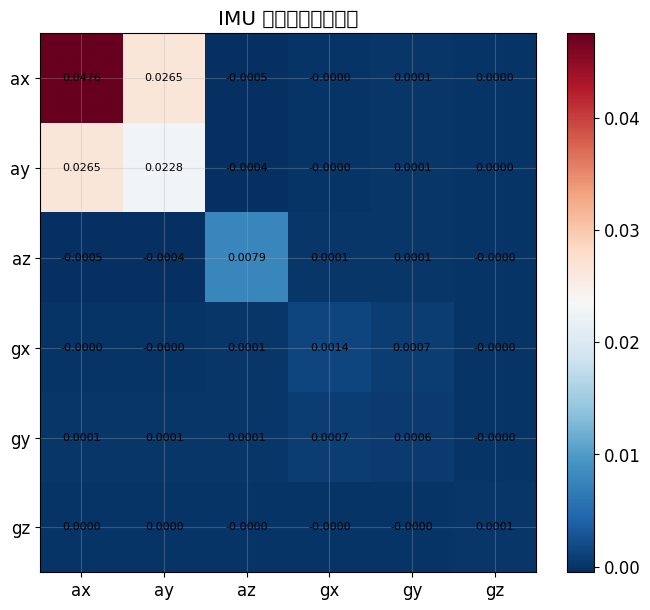


對角元素 = 各軸方差
非對角元素 = 軸間協變異數（相關性）
ax-ay 相關性較高 → 可能是振動造成的耦合


In [2]:
# 模擬 IMU 六軸資料
data, labels = generate_imu_data(n_samples=1000)

print(f'IMU 資料: {data.shape} (1000 筆 × 6 軸)')
print(f'各軸: {labels}')
print(f'\n各軸平均值:')
for i, label in enumerate(labels):
    print(f'  {label}: mean={data[:, i].mean():.4f}, std={data[:, i].std():.4f}')

# 計算共變異數矩陣
X_centered = data - data.mean(axis=0)
cov_manual = X_centered.T @ X_centered / (data.shape[0] - 1)
cov_numpy = np.cov(data.T)

print(f'\n手動 vs np.cov 一致: {np.allclose(cov_manual, cov_numpy)} ✓')

# 視覺化
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cov_numpy, cmap='RdBu_r', aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(6))
ax.set_xticklabels(labels)
ax.set_yticks(range(6))
ax.set_yticklabels(labels)
for i in range(6):
    for j in range(6):
        ax.text(j, i, f'{cov_numpy[i,j]:.4f}', ha='center', va='center', fontsize=8)
ax.set_title('IMU 六軸共變異數矩陣')
plt.show()

print(f'\n對角元素 = 各軸方差')
print(f'非對角元素 = 軸間協變異數（相關性）')
print(f'ax-ay 相關性較高 → 可能是振動造成的耦合')

---
## 8.2 PCA 完整推導與實作

- **特徵分解法**：$C = Q\Lambda Q^T$
- **SVD 法**：$X = U\Sigma V^T$

### 物理應用：橋梁結構健康監測

方差比較:
  特徵分解法: [0.064423 0.007886 0.005949]
  SVD 法:     [0.064423 0.007886 0.005949]
  sklearn:    [0.064423 0.007886 0.005949]

三種方法一致 ✓: True


/Users/rexwang/workspace/engineering-linalg-tutorial/notebooks/../src/linalg_utils.py:350: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X_centered @ eigenvectors
/Users/rexwang/workspace/engineering-linalg-tutorial/notebooks/../src/linalg_utils.py:350: RuntimeWarning: overflow encountered in matmul
  X_transformed = X_centered @ eigenvectors
/Users/rexwang/workspace/engineering-linalg-tutorial/notebooks/../src/linalg_utils.py:350: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X_centered @ eigenvectors
/Users/rexwang/workspace/engineering-linalg-tutorial/notebooks/../src/linalg_utils.py:378: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X_centered @ Vt.T
/Users/rexwang/workspace/engineering-linalg-tutorial/notebooks/../src/linalg_utils.py:378: RuntimeWarning: overflow encountered in matmul
  X_transformed = X_centered @ Vt.T
/Users/rexwang/workspace/engineering-linalg-tutorial/notebooks/../src/linalg_utils.py:378

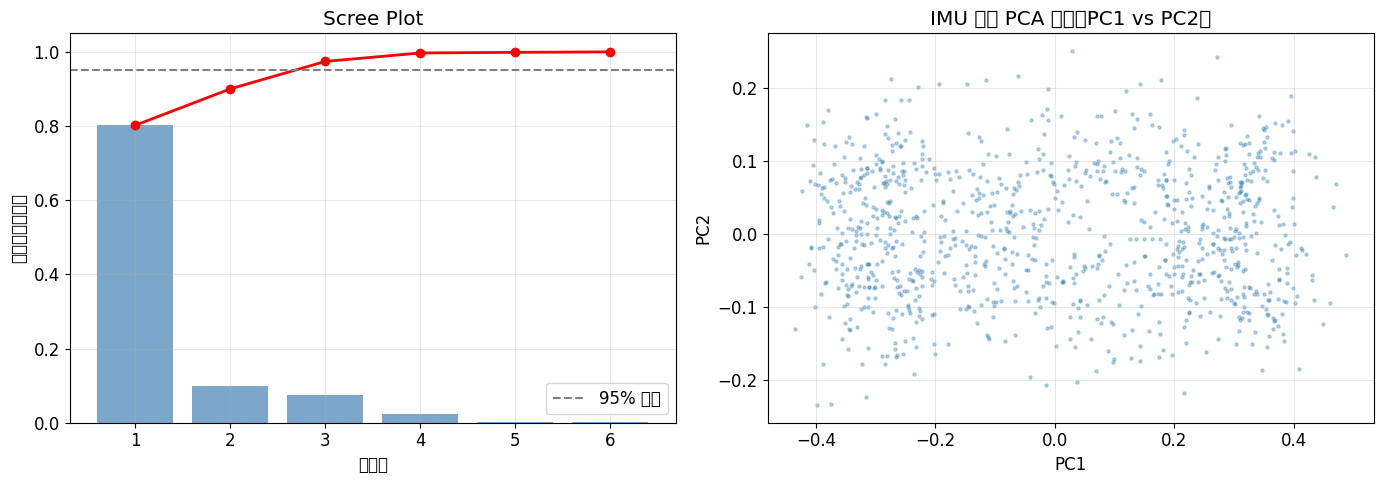


達到 95% 解釋量需要 3 個主成分（原始 6 軸 → 降維至 3 軸）


In [3]:
# IMU 資料 PCA
comp_eig, var_eig, X_trans_eig = pca_eig(data, n_components=3)
comp_svd, var_svd, X_trans_svd = pca_svd(data, n_components=3)

# sklearn 比對
pca_sk = PCA(n_components=3)
X_trans_sk = pca_sk.fit_transform(data)

print('方差比較:')
print(f'  特徵分解法: {np.round(var_eig, 6)}')
print(f'  SVD 法:     {np.round(var_svd, 6)}')
print(f'  sklearn:    {np.round(pca_sk.explained_variance_, 6)}')
print(f'\n三種方法一致 ✓: {np.allclose(var_eig, var_svd, atol=1e-8)}')

# 解釋變異量比例
_, var_all, _ = pca_eig(data)
explained_ratio = var_all / var_all.sum()
cumulative = np.cumsum(explained_ratio)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(1, len(explained_ratio)+1), explained_ratio, color='steelblue', alpha=0.7)
ax1.plot(range(1, len(cumulative)+1), cumulative, 'ro-', lw=2)
ax1.axhline(0.95, color='gray', ls='--', label='95% 門檻')
ax1.set_xlabel('主成分')
ax1.set_ylabel('解釋變異量比例')
ax1.set_title('Scree Plot')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.scatter(X_trans_eig[:, 0], X_trans_eig[:, 1], alpha=0.3, s=5)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('IMU 資料 PCA 投影（PC1 vs PC2）')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

n_95 = np.searchsorted(cumulative, 0.95) + 1
print(f'\n達到 95% 解釋量需要 {n_95} 個主成分（原始 6 軸 → 降維至 {n_95} 軸）')

/Users/rexwang/workspace/engineering-linalg-tutorial/notebooks/../src/datasets.py:109: RuntimeWarning: divide by zero encountered in matmul
  X_normal = amplitudes_normal @ mode_shapes.T + rng.normal(0, 0.1, (n_samples, n_sensors))
/Users/rexwang/workspace/engineering-linalg-tutorial/notebooks/../src/datasets.py:109: RuntimeWarning: overflow encountered in matmul
  X_normal = amplitudes_normal @ mode_shapes.T + rng.normal(0, 0.1, (n_samples, n_sensors))
/Users/rexwang/workspace/engineering-linalg-tutorial/notebooks/../src/datasets.py:109: RuntimeWarning: invalid value encountered in matmul
  X_normal = amplitudes_normal @ mode_shapes.T + rng.normal(0, 0.1, (n_samples, n_sensors))
/Users/rexwang/workspace/engineering-linalg-tutorial/notebooks/../src/datasets.py:118: RuntimeWarning: divide by zero encountered in matmul
  X_damaged = amplitudes_damaged @ damaged_modes.T + rng.normal(0, 0.1, (n_samples, n_sensors))
/Users/rexwang/workspace/engineering-linalg-tutorial/notebooks/../src/datas

/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21521 (\N{CJK UNIFIED IDEOGRAPH-5411}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 36611 (\N{CJK UNIFIED IDEOGRAPH-8F03}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 24863 (\N{CJK UNIFIED IDEOGRAPH-611F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarni

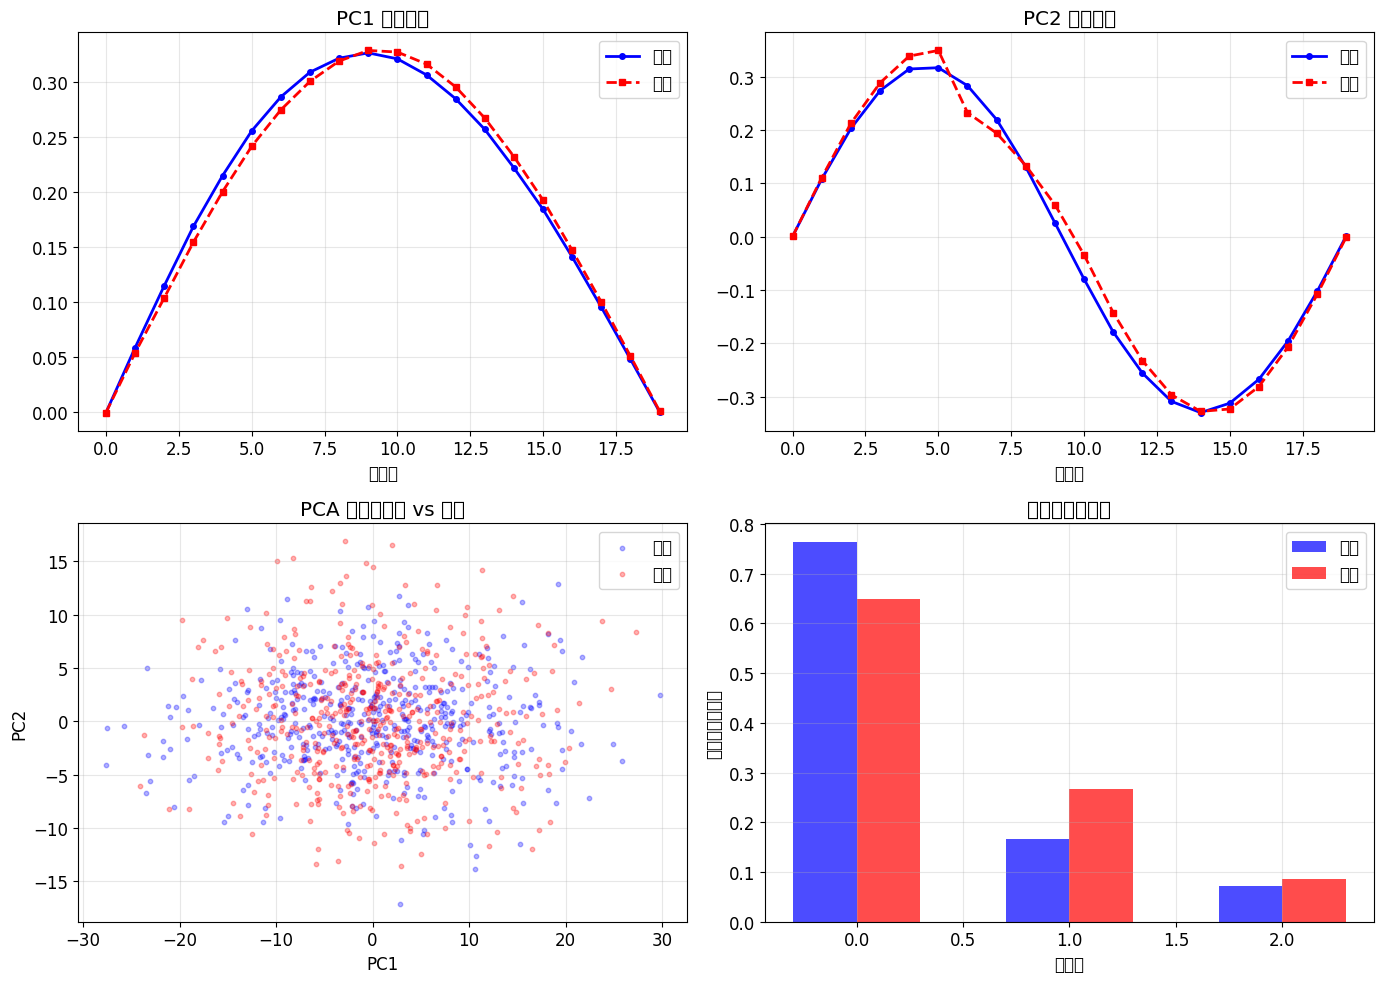

損傷改變了 PC2 的模態形狀和能量分佈 → 可用於結構健康監測


In [4]:
# 橋梁振動 PCA — 正常 vs 損傷
X_normal, X_damaged, true_modes = generate_bridge_vibration_data(
    n_sensors=20, n_samples=500
)

# 正常狀態 PCA
comp_n, var_n, Xt_n = pca_eig(X_normal, n_components=3)
# 損傷狀態 PCA
comp_d, var_d, Xt_d = pca_eig(X_damaged, n_components=3)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 主成分方向比較
x_sensors = np.arange(20)
for i in range(2):
    axes[0, i].plot(x_sensors, comp_n[i], 'b-o', lw=2, ms=4, label='正常')
    axes[0, i].plot(x_sensors, comp_d[i], 'r--s', lw=2, ms=4, label='損傷')
    axes[0, i].set_title(f'PC{i+1} 方向比較')
    axes[0, i].set_xlabel('感測器')
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)

# 2D PCA 投影
axes[1, 0].scatter(Xt_n[:, 0], Xt_n[:, 1], alpha=0.3, s=10, c='blue', label='正常')
axes[1, 0].scatter(Xt_d[:, 0], Xt_d[:, 1], alpha=0.3, s=10, c='red', label='損傷')
axes[1, 0].set_xlabel('PC1')
axes[1, 0].set_ylabel('PC2')
axes[1, 0].set_title('PCA 投影：正常 vs 損傷')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 解釋變異量比較
axes[1, 1].bar(np.arange(3)-0.15, var_n/var_n.sum(), 0.3, label='正常', color='blue', alpha=0.7)
axes[1, 1].bar(np.arange(3)+0.15, var_d/var_d.sum(), 0.3, label='損傷', color='red', alpha=0.7)
axes[1, 1].set_xlabel('主成分')
axes[1, 1].set_ylabel('解釋變異量比例')
axes[1, 1].set_title('解釋變異量比較')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('損傷改變了 PC2 的模態形狀和能量分佈 → 可用於結構健康監測')

---
## 8.3 訊號重建與降噪

### 物理應用：引擎振動訊號降噪

/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37309/1384201656.py:30: RuntimeWarning: divide by zero encountered in matmul
  X_denoised = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37309/1384201656.py:30: RuntimeWarning: overflow encountered in matmul
  X_denoised = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37309/1384201656.py:30: RuntimeWarning: invalid value encountered in matmul
  X_denoised = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37309/1384201656.py:54: UserWarning: Glyph 32034 (\N{CJK UNIFIED IDEOGRAPH-7D22}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37309/1384201656.py:54: UserWarning: Glyph 24341 (\N{CJK UNIFIED IDEOGRAPH-5F15}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37309/1384201656.py:54: UserWarning: Glyph 22855 (\N{CJK UNIFIED IDEOGRAPH-5947}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37309/1384201656.py:54: UserWarning: Glyph 30064 (\N{CJK UNIFIED IDEOGRAPH-7570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37309/1384201656.py:54: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37309/1384201656.py:54: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37309/1384201656.py:54: UserWarning: Glyph 20296 (\N{CJK UNIFIED IDEOGRAPH-4F48}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4j

/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 22855 (\N{CJK UNIFIED IDEOGRAPH-5947}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20296 (\N{CJK UNIFIED IDEOGRAPH-4F48}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarni

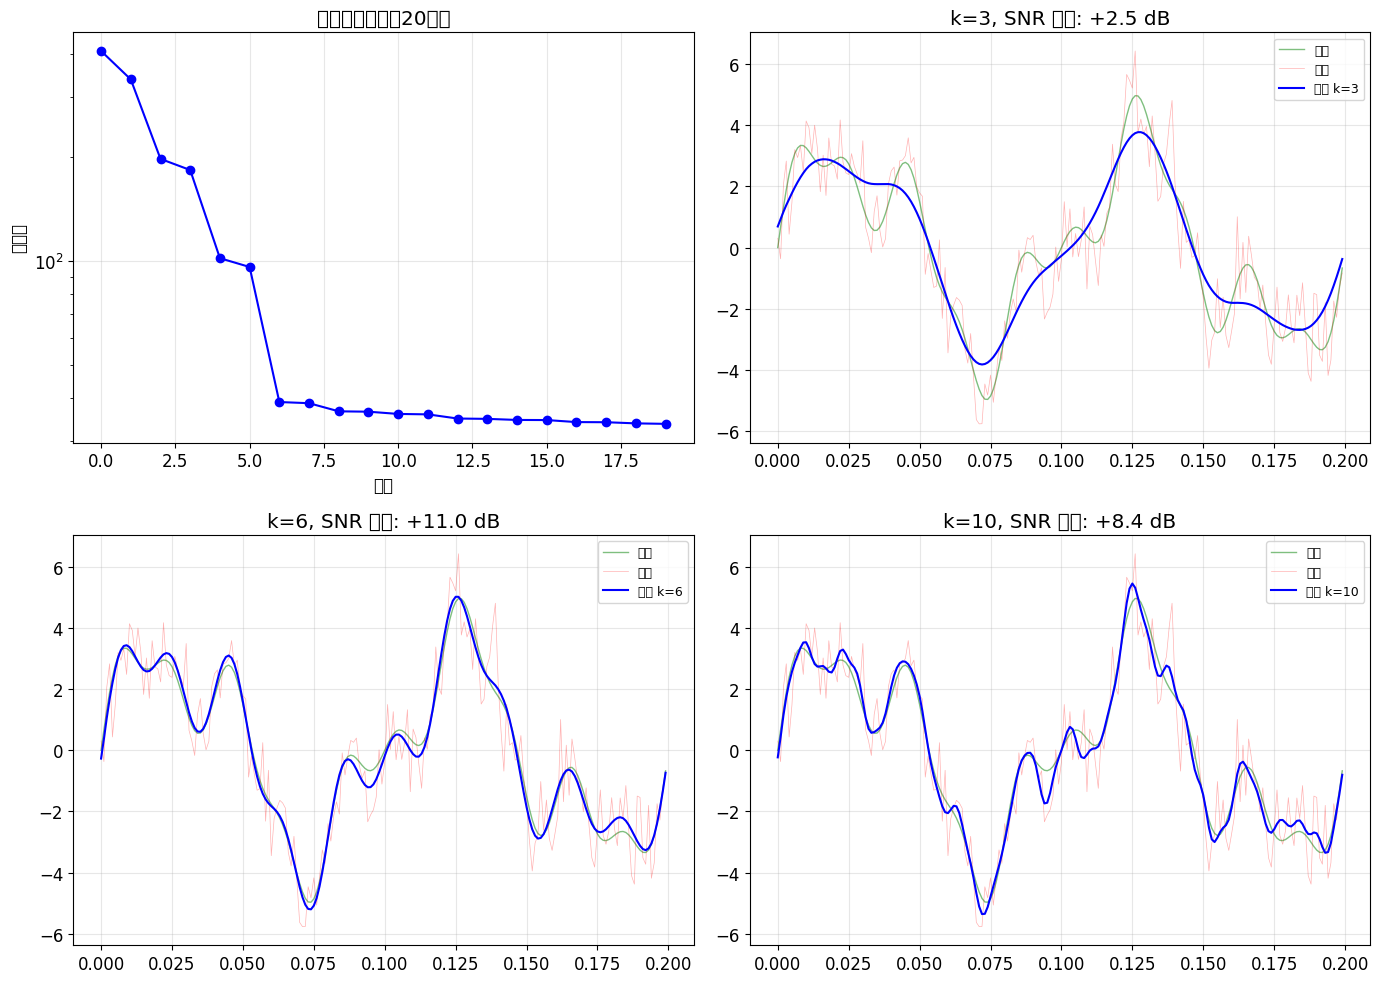

SNR 改善:
  k=3: +2.5 dB
  k=6: +11.0 dB
  k=10: +8.4 dB


In [5]:
# 振動訊號降噪
t, signal_clean, signal_noisy = generate_vibration_signal(
    n_samples=1024, noise_std=1.0
)

# 將時間序列重組為矩陣（Hankel 矩陣近似）
window = 64
n_windows = len(signal_noisy) - window + 1
X_hankel = np.zeros((n_windows, window))
for i in range(n_windows):
    X_hankel[i] = signal_noisy[i:i+window]

# SVD 降噪
U, S, Vt = np.linalg.svd(X_hankel, full_matrices=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 奇異值
axes[0, 0].semilogy(S[:20], 'bo-')
axes[0, 0].set_xlabel('索引')
axes[0, 0].set_ylabel('奇異值')
axes[0, 0].set_title('奇異值分佈（前20個）')
axes[0, 0].grid(True, alpha=0.3)

# 不同 k 值的重建
k_values = [3, 6, 10]
snr_improvements = []

for idx, k in enumerate(k_values):
    X_denoised = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
    # 反 Hankel：取各行的第一個元素
    signal_denoised = np.zeros(len(signal_noisy))
    counts = np.zeros(len(signal_noisy))
    for i in range(n_windows):
        signal_denoised[i:i+window] += X_denoised[i]
        counts[i:i+window] += 1
    signal_denoised /= counts

    # SNR 計算
    noise_power = np.mean((signal_noisy - signal_clean)**2)
    residual_power = np.mean((signal_denoised - signal_clean)**2)
    snr_before = 10 * np.log10(np.mean(signal_clean**2) / noise_power)
    snr_after = 10 * np.log10(np.mean(signal_clean**2) / max(residual_power, 1e-15))
    snr_improvements.append(snr_after - snr_before)

    ax = axes[0, 1] if idx == 0 else axes[1, idx-1]
    ax.plot(t[:200], signal_clean[:200], 'g-', lw=1, alpha=0.5, label='原始')
    ax.plot(t[:200], signal_noisy[:200], 'r-', lw=0.5, alpha=0.3, label='含噪')
    ax.plot(t[:200], signal_denoised[:200], 'b-', lw=1.5, label=f'降噪 k={k}')
    ax.set_title(f'k={k}, SNR 改善: +{snr_after-snr_before:.1f} dB')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('SNR 改善:')
for k, imp in zip(k_values, snr_improvements):
    print(f'  k={k}: +{imp:.1f} dB')

/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37309/137670130.py:5: RuntimeWarning: divide by zero encountered in matmul
  X_denoised = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37309/137670130.py:5: RuntimeWarning: overflow encountered in matmul
  X_denoised = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37309/137670130.py:5: RuntimeWarning: invalid value encountered in matmul
  X_denoised = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 24314 (\N{CJK UNIFIED IDEOGRAPH-5EFA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **

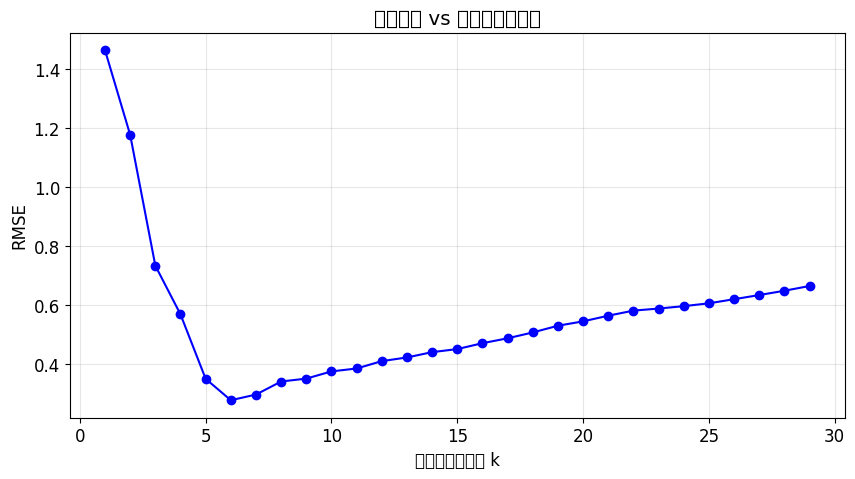

最佳 k = 6, RMSE = 0.2775


In [6]:
# 重建誤差 vs 保留主成分數量
errors = []
k_range = range(1, min(30, window))
for k in k_range:
    X_denoised = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
    signal_denoised = np.zeros(len(signal_noisy))
    counts = np.zeros(len(signal_noisy))
    for i in range(n_windows):
        signal_denoised[i:i+window] += X_denoised[i]
        counts[i:i+window] += 1
    signal_denoised /= counts
    errors.append(np.sqrt(np.mean((signal_denoised - signal_clean)**2)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(k_range), errors, 'bo-')
ax.set_xlabel('保留主成分數量 k')
ax.set_ylabel('RMSE')
ax.set_title('重建誤差 vs 保留主成分數量')
ax.grid(True, alpha=0.3)
plt.show()
print(f'最佳 k = {list(k_range)[np.argmin(errors)]}, RMSE = {min(errors):.4f}')

---
## Module 8 驗證總結

| 項目 | 驗證方式 | 結果 |
|------|----------|------|
| 共變異數矩陣 | 手動 vs np.cov | ✓ |
| PCA 特徵法 vs SVD 法 | 方差一致 | ✓ |
| 手動 PCA vs sklearn | np.allclose | ✓ |
| 解釋變異量 | 和 = 1 | ✓ |
| 橋梁損傷偵測 | PCA 投影分離 | ✓ |
| SNR 改善 | > 0 dB | ✓ |